## Libraries

In [ ]:
!pip install roboflow
!pip install torchvision
!pip install opencv-python

import os
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from roboflow import Roboflow
import json
from collections import Counter
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


## Dataset from Roboflow

In [ ]:
rf = Roboflow(api_key="your_key_here")
project = rf.workspace("atif-syahanim-s-workspace").project("idsc-fah-glaucoma")
dataset = project.version(3).download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to IDSC-FAH-Glaucoma-3 in coco:: 100%|██████████| 741/741 [00:00<00:00, 4298.72it/s]


In [ ]:
json_path = "/content/IDSC-FAH-Glaucoma-3/train/_annotations.coco.json"
with open(json_path) as f:
    coco_data = json.load(f)

# Keep only 'positive' and 'negative'
new_categories = [
    {"id": 0, "name": "negative", "supercategory": "none"},
    {"id": 1, "name": "positive", "supercategory": "none"}
]

# Map old ids to new ids
id_map = {0: None, 1: 0, 2: 1}  # 0 - neg, 1 - pos

# Filter annotations and remap category_ids
new_annotations = []
for ann in coco_data['annotations']:
    new_id = id_map[ann['category_id']]
    if new_id is not None:
        ann['category_id'] = new_id
        new_annotations.append(ann)

# Update JSON
coco_data['categories'] = new_categories
coco_data['annotations'] = new_annotations

# Save back
with open("/content/IDSC-FAH-Glaucoma-3/train/_annotations.coco.json", "w") as f:
    json.dump(coco_data, f)

In [ ]:
with open("/content/IDSC-FAH-Glaucoma-3/train/_annotations.coco.json") as f:
    coco_data = json.load(f)

print(coco_data.keys())  # should show 'images', 'annotations', 'categories', etc.
print(len(coco_data['images']))  # number of images
print(coco_data['categories'])  # the label categories

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
737
[{'id': 0, 'name': 'negative', 'supercategory': 'none'}, {'id': 1, 'name': 'positive', 'supercategory': 'none'}]


In [ ]:
# check if all labels are 0 and 1
# Load the COCO annotations
with open("/content/IDSC-FAH-Glaucoma-3/train/_annotations.coco.json") as f:
    coco_data = json.load(f)

# Collect all unique category_ids
category_ids = set(ann['category_id'] for ann in coco_data['annotations'])

print("Unique category_ids in annotations:", category_ids)

# Optional: check if anything is outside expected IDs
expected_ids = {0, 1}
invalid_ids = category_ids - expected_ids
if invalid_ids:
    print("⚠️ Found unexpected category_ids:", invalid_ids)
else:
    print("✅ All annotations use correct category_ids (0 or 1).")

Unique category_ids in annotations: {0, 1}
✅ All annotations use correct category_ids (0 or 1).


In [ ]:
# count class
category_counts = Counter([ann['category_id'] for ann in coco_data['annotations']])
print(category_counts)

Counter({1: 540, 0: 197})


## Preprocessing

In [ ]:
train_dir = "/content/IDSC-FAH-Glaucoma-3/train"
json_path = os.path.join(train_dir, "_annotations.coco.json")
csv_path = "/content/Labels.csv"  # your CSV path

# load Labels.csv
df = pd.read_csv(csv_path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# custom dataset
class GlaucomaDatasetWithQuality(Dataset):
    def __init__(self, coco_json, image_folder, csv_file, transform=None):
        self.image_folder = image_folder
        self.transform = transform

        # Load COCO JSON
        with open(coco_json) as f:
            coco_data = json.load(f)

        # Map image id → file_name
        self.image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}

        # Map image id → label (0 or 1)
        self.image_id_to_label = {}
        for ann in coco_data['annotations']:
            self.image_id_to_label[ann['image_id']] = ann['category_id']

        # List of image_ids for indexing
        self.image_ids = list(self.image_id_to_label.keys())

        # Load CSV quality scores
        self.df = csv_file.copy()
        self.df['img_base'] = self.df['Image Name'].apply(lambda x: x.split('_')[0])
        self.quality_map = dict(zip(self.df['img_base'], self.df['Quality Score']))

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        file_name = self.image_id_to_file[img_id]
        label = self.image_id_to_label[img_id]

        img_path = os.path.join(self.image_folder, file_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        img_base = file_name.split('_')[0]
        quality = self.quality_map.get(img_base, 5.0)  # default quality 5 if missing

        return image, torch.tensor(label, dtype=torch.float32), torch.tensor(quality, dtype=torch.float32)

# transformation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = GlaucomaDatasetWithQuality(json_path, train_dir, df, transform=None)

# get all labels
labels = [full_dataset[i][1].item() for i in range(len(full_dataset))]

# stratified split
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = Subset(
    GlaucomaDatasetWithQuality(json_path, train_dir, df, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    GlaucomaDatasetWithQuality(json_path, train_dir, df, transform=val_transform),
    val_idx
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
train_labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
val_labels = [val_dataset[i][1].item() for i in range(len(val_dataset))]

print("Train distribution:", Counter(train_labels))
print("Val distribution:", Counter(val_labels))

Train distribution: Counter({1.0: 432, 0.0: 157})
Val distribution: Counter({1.0: 108, 0.0: 40})


## Model Training

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Epoch [1/20] Train Loss: 0.7408 Val Loss: 0.5802 Val Acc: 0.7703
Epoch [2/20] Train Loss: 0.5566 Val Loss: 0.4908 Val Acc: 0.8649
Epoch [3/20] Train Loss: 0.4648 Val Loss: 0.4203 Val Acc: 0.8784
Epoch [4/20] Train Loss: 0.3728 Val Loss: 0.3813 Val Acc: 0.8919
Epoch [5/20] Train Loss: 0.3226 Val Loss: 0.3311 Val Acc: 0.8986
Epoch [6/20] Train Loss: 0.2823 Val Loss: 0.2918 Val Acc: 0.9189
Epoch [7/20] Train Loss: 0.2500 Val Loss: 0.2709 Val Acc: 0.9189
Epoch [8/20] Train Loss: 0.2401 Val Loss: 0.2481 Val Acc: 0.9257
Epoch [9/20] Train Loss: 0.2106 Val Loss: 0.2492 Val Acc: 0.9122
Epoch [10/20] Train Loss: 0.1949 Val Loss: 0.2284 Val Acc: 0.9257
Epoch [11/20] Train Loss: 0.1607 Val Loss: 0.2177 Val Acc: 0.9257
Epoch [12/20] Train Loss: 0.1637 Val Loss: 0.2136 Val Acc: 0.9257
Epoch [13/20] Train Loss: 0.1437 Val Loss: 0.2089 Val Acc: 0.9257
Epoch [14/20] Train Loss: 0.1618 Val Loss: 0.2048 Val Acc: 0.9257
Epoch [15/20] Train Loss: 0.1283 Val Loss: 0.2034 Val Acc: 0.9122
Epoch [16/20] Train

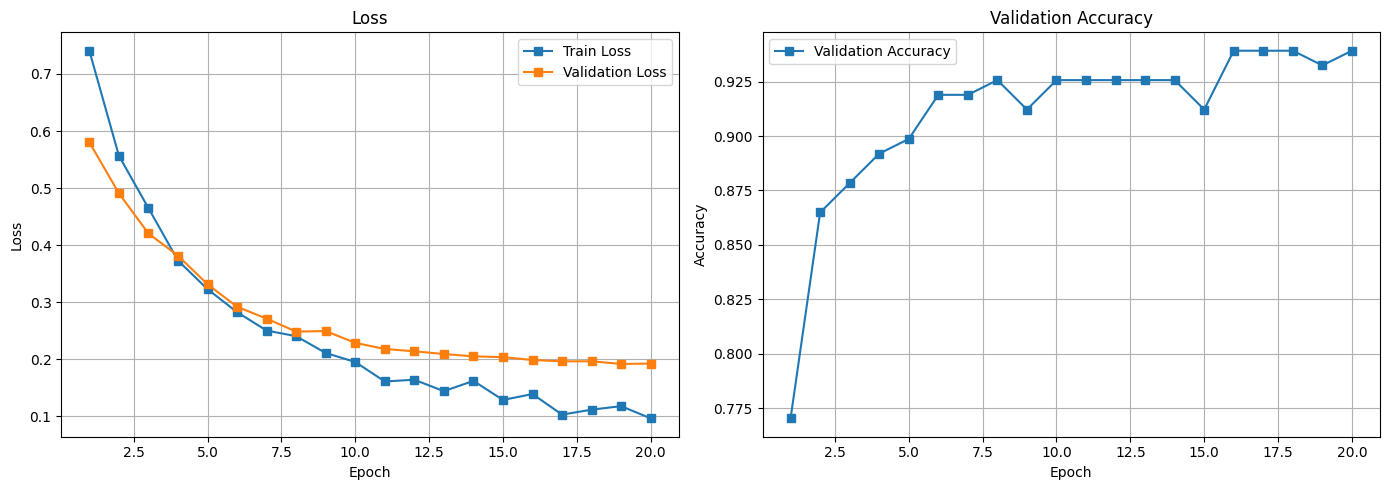


----- Validation Metrics -----
Precision : 0.9459
Recall    : 0.9722
F1-score  : 0.9589

Confusion Matrix:
[[ 34   6]
 [  3 105]]


In [ ]:
# model 1
model = models.resnet18(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Optimizer: only layer4 + fc
optimizer = optim.Adam(
    list(model.layer4.parameters()) + list(model.fc.parameters()),
    lr=1e-5
)

# training setup
num_epochs = 20
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels, quality in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        quality = quality.unsqueeze(1).to(device)

        weights = (quality / 10.0) + 0.5

        optimizer.zero_grad()
        outputs = model(images)

        loss_fn = nn.BCEWithLogitsLoss(weight=weights)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss, correct = 0.0, 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for images, labels, quality in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            quality = quality.unsqueeze(1).to(device)

            weights = (quality / 10.0) + 0.5

            outputs = model(images)
            loss_fn = nn.BCEWithLogitsLoss(weight=weights)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.byte()).sum().item()

            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # Save model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_1.pth")

# plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
epochs = range(1, num_epochs+1)

axes[0].plot(epochs, train_losses, label='Train Loss', marker='s')
axes[0].plot(epochs, val_losses, label='Validation Loss', marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, val_accs, label='Validation Accuracy', marker='s')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# performance metrics
precision = precision_score(val_labels, val_preds)
recall = recall_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)
cm = confusion_matrix(val_labels, val_preds)

print("\n----- Validation Metrics -----")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


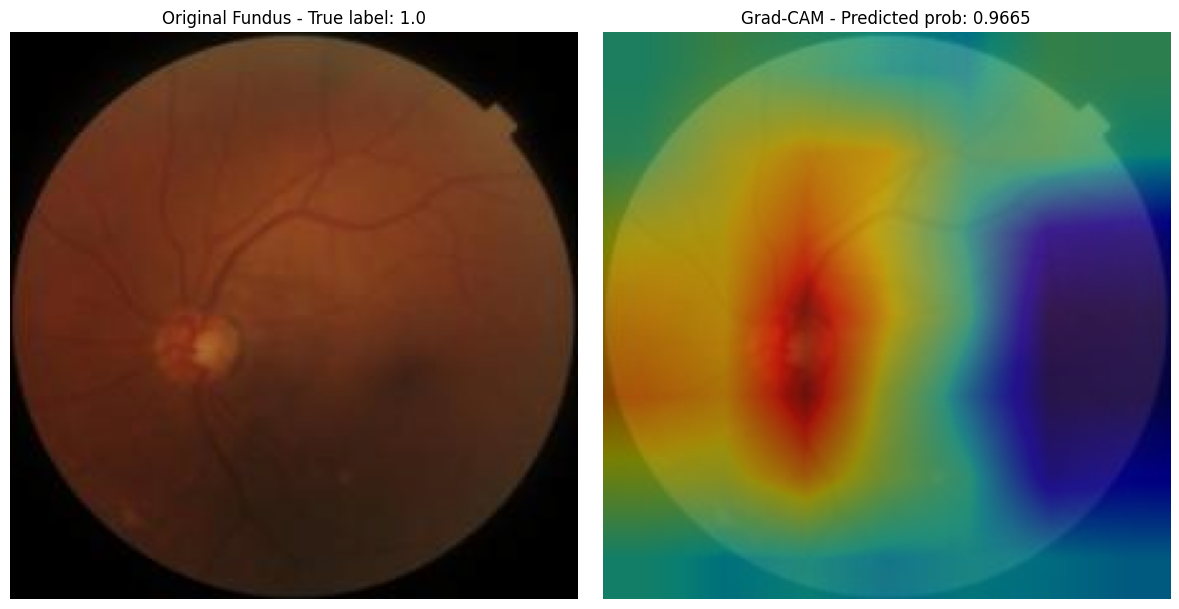

In [ ]:
model.load_state_dict(torch.load("model_1.pth"))
model.eval()

grad_cam = GradCAM(model, model.layer4)

# pick a sample from validation set
val_img, val_label, _ = val_dataset[11]
heatmap, prob = grad_cam.generate(val_img)

# unnormalize the original image for proper visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = val_img.numpy().transpose(1,2,0)  # C,H,W -> H,W,C
img_np = std * img_np + mean                # unnormalize
img_np = np.clip(img_np, 0, 1)             # clamp to valid range

# --------------------------
# Side-by-side plot: raw fundus + Grad-CAM
# --------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f'Original Fundus - True label: {val_label}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f'Grad-CAM - Predicted prob: {prob:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Epoch [1/20] Train Loss: 0.2637 Val Loss: 0.1875 Val Acc: 0.8581
Epoch [2/20] Train Loss: 0.1371 Val Loss: 0.1277 Val Acc: 0.8851
Epoch [3/20] Train Loss: 0.0858 Val Loss: 0.1047 Val Acc: 0.9189
Epoch [4/20] Train Loss: 0.0646 Val Loss: 0.1133 Val Acc: 0.9257
Epoch [5/20] Train Loss: 0.0468 Val Loss: 0.1018 Val Acc: 0.9459
Epoch [6/20] Train Loss: 0.0392 Val Loss: 0.0950 Val Acc: 0.9324
Epoch [7/20] Train Loss: 0.0546 Val Loss: 0.1050 Val Acc: 0.9459
Epoch [8/20] Train Loss: 0.0411 Val Loss: 0.1030 Val Acc: 0.9662
Epoch [9/20] Train Loss: 0.0336 Val Loss: 0.0941 Val Acc: 0.9324
Epoch [10/20] Train Loss: 0.0290 Val Loss: 0.0976 Val Acc: 0.9595
Epoch [11/20] Train Loss: 0.0214 Val Loss: 0.1008 Val Acc: 0.9595
Epoch [12/20] Train Loss: 0.0216 Val Loss: 0.1148 Val Acc: 0.9527
Epoch [13/20] Train Loss: 0.0175 Val Loss: 0.1104 Val Acc: 0.9527
Epoch [14/20] Train Loss: 0.0196 Val Loss: 0.1278 Val Acc: 0.9527
Epoch [15/20] Train Loss: 0.0174 Val Loss: 0.1188 Val Acc: 0.9527
Epoch [16/20] Train

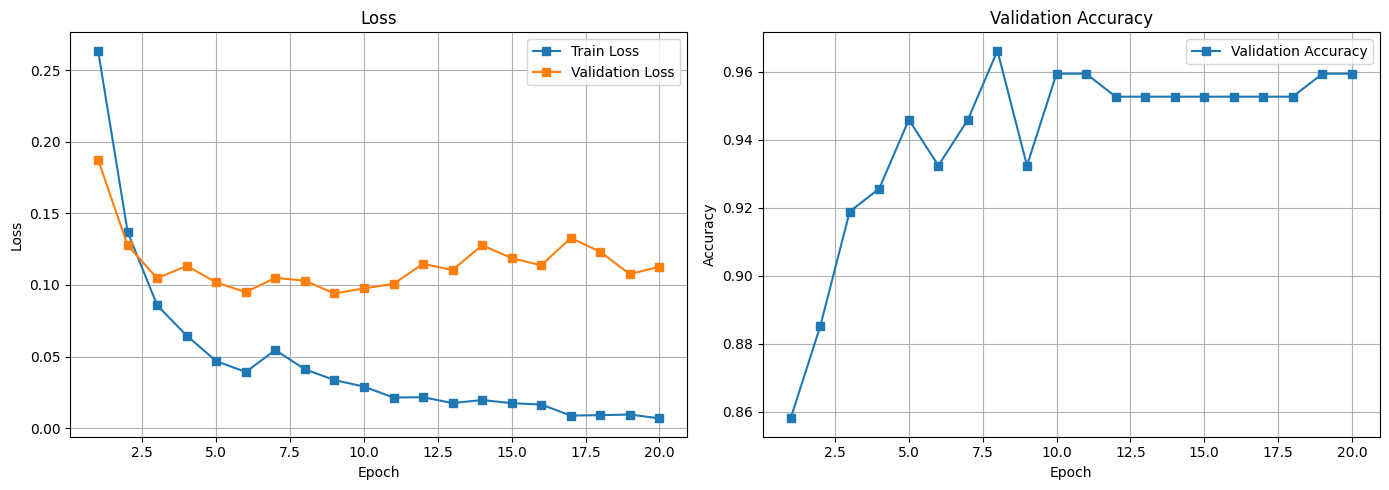


----- Validation Metrics -----
Precision : 0.9722
Recall    : 0.9722
F1-score  : 0.9722

Confusion Matrix:
[[ 37   3]
 [  3 105]]


In [ ]:
# model 2
model = models.resnet18(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 + layer4
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# -------------------------
# Loss (handle imbalance)
# -------------------------
# based on your dataset: 540 pos, 197 neg
pos_weight = torch.tensor([197 / 540]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# -------------------------
# Optimizer
# -------------------------
optimizer = optim.Adam(
    list(model.layer3.parameters()) +
    list(model.layer4.parameters()) +
    list(model.fc.parameters()),
    lr=3e-5
)

# -------------------------
# Training setup
# -------------------------
num_epochs = 20
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')

# -------------------------
# Training loop
# -------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels, quality in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).float().to(device)  # convert to float

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    val_loss, correct = 0.0, 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for images, labels, quality in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            correct += (preds == labels.byte()).sum().item()

            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_2.pth")

# -------------------------
# Plot results
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))
epochs = range(1, num_epochs+1)

axes[0].plot(epochs, train_losses, label='Train Loss', marker='s')
axes[0].plot(epochs, val_losses, label='Validation Loss', marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, val_accs, label='Validation Accuracy', marker='s')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# -------------------------
# Final Metrics
# -------------------------
precision = precision_score(val_labels, val_preds)
recall = recall_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)
cm = confusion_matrix(val_labels, val_preds)

print("\n----- Validation Metrics -----")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

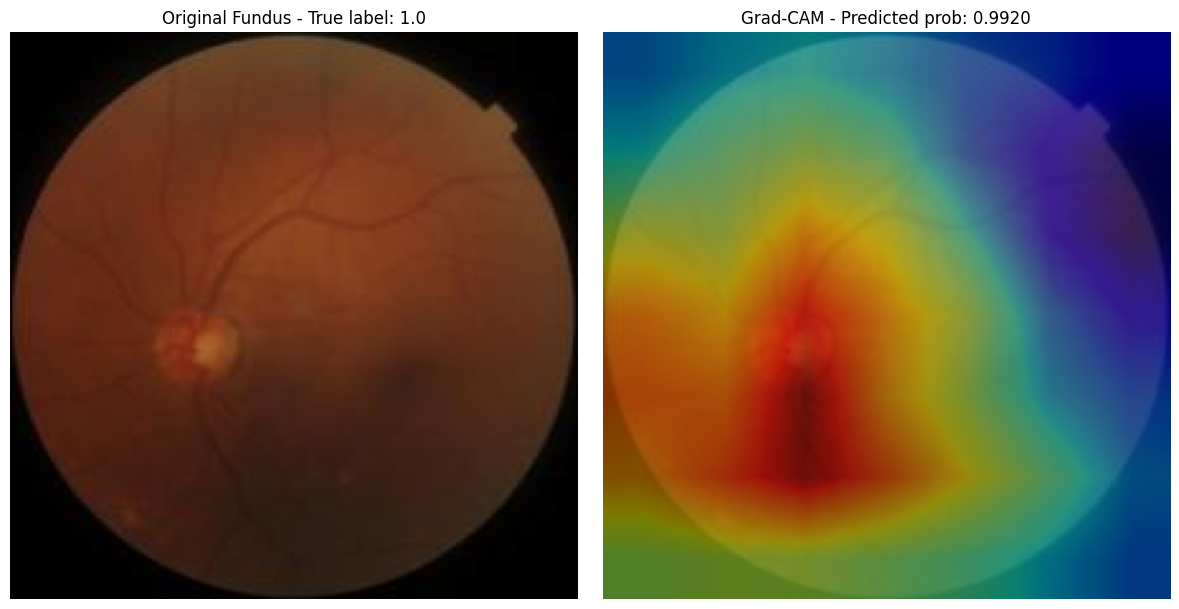

In [ ]:
model.load_state_dict(torch.load("model_2.pth"))
model.eval()

grad_cam = GradCAM(model, model.layer4)

# pick a sample from validation set
val_img, val_label, _ = val_dataset[11]  # first sample
heatmap, prob = grad_cam.generate(val_img)

# unnormalize the original image for proper visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = val_img.numpy().transpose(1,2,0)  # C,H,W -> H,W,C
img_np = std * img_np + mean                # unnormalize
img_np = np.clip(img_np, 0, 1)             # clamp to valid range

# --------------------------
# Side-by-side plot: raw fundus + Grad-CAM
# --------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f'Original Fundus - True label: {val_label}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f'Grad-CAM - Predicted prob: {prob:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# model 3 - freeze all layer except 4,fc, use pos weight

model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Pos_weight = count(0)/count(1)
train_labels = [full_dataset[i][1].item() for i in train_idx]
pos_weight = torch.tensor(train_labels.count(0)/train_labels.count(1)).to(device)

optimizer = optim.Adam(list(model.layer4.parameters()) + list(model.fc.parameters()), lr=1e-5)

# Training loop same as model 1/2
num_epochs = 20
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels, quality in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss, correct = 0.0, 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for images, labels, quality in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)
            loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.byte()).sum().item()
            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_3.pth")

# Performance metrics
precision = precision_score(val_labels, val_preds)
recall = recall_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)
cm = confusion_matrix(val_labels, val_preds)

print("\n----- Validation Metrics -----")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Epoch [1/20] Train Loss: 0.3600 Val Loss: 0.3196 Val Acc: 0.7973
Epoch [2/20] Train Loss: 0.2708 Val Loss: 0.2423 Val Acc: 0.8716
Epoch [3/20] Train Loss: 0.2184 Val Loss: 0.2019 Val Acc: 0.8919
Epoch [4/20] Train Loss: 0.1824 Val Loss: 0.1752 Val Acc: 0.8919
Epoch [5/20] Train Loss: 0.1484 Val Loss: 0.1535 Val Acc: 0.8986
Epoch [6/20] Train Loss: 0.1326 Val Loss: 0.1375 Val Acc: 0.8986
Epoch [7/20] Train Loss: 0.1242 Val Loss: 0.1275 Val Acc: 0.9054
Epoch [8/20] Train Loss: 0.1087 Val Loss: 0.1209 Val Acc: 0.9324
Epoch [9/20] Train Loss: 0.1034 Val Loss: 0.1145 Val Acc: 0.9257
Epoch [10/20] Train Loss: 0.0860 Val Loss: 0.1139 Val Acc: 0.9392
Epoch [11/20] Train Loss: 0.0771 Val Loss: 0.1063 Val Acc: 0.9324
Epoch [12/20] Train Loss: 0.0765 Val Loss: 0.1034 Val Acc: 0.9324
Epoch [13/20] Train Loss: 0.0816 Val Loss: 0.1023 Val Acc: 0.9324
Epoch [14/20] Train Loss: 0.0637 Val Loss: 0.1017 Val Acc: 0.9324
Epoch [15/20] Train Loss: 0.0692 Val Loss: 0.1030 Val Acc: 0.9392
Epoch [16/20] Train

Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


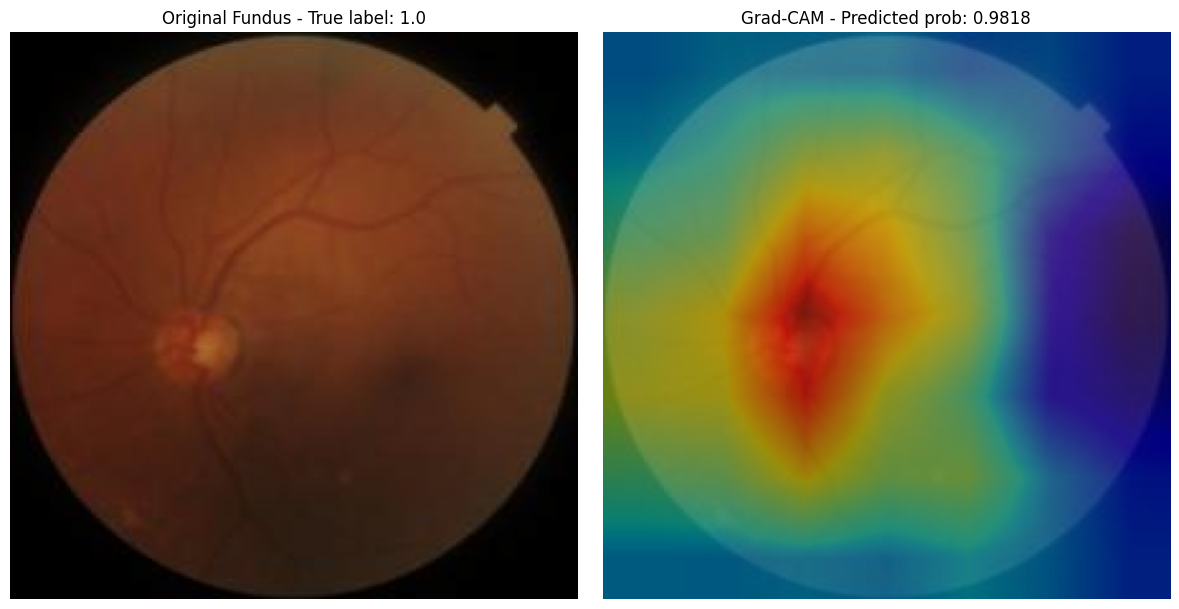

In [ ]:
model.load_state_dict(torch.load("model_3.pth"))
model.eval()

grad_cam = GradCAM(model, model.layer4)

# pick a sample from validation set
val_img, val_label, _ = val_dataset[11]  # first sample
heatmap, prob = grad_cam.generate(val_img)

# unnormalize the original image for proper visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = val_img.numpy().transpose(1,2,0)  # C,H,W -> H,W,C
img_np = std * img_np + mean                # unnormalize
img_np = np.clip(img_np, 0, 1)             # clamp to valid range

# --------------------------
# Side-by-side plot: raw fundus + Grad-CAM
# --------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f'Original Fundus - True label: {val_label}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f'Grad-CAM - Predicted prob: {prob:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Epoch [1/20] Train Loss: 0.1445 Val Loss: 0.1016 Val Acc: 0.9189
Epoch [2/20] Train Loss: 0.0638 Val Loss: 0.1138 Val Acc: 0.9257
Epoch [3/20] Train Loss: 0.0521 Val Loss: 0.1266 Val Acc: 0.9459
Epoch [4/20] Train Loss: 0.0286 Val Loss: 0.0936 Val Acc: 0.9595
Epoch [5/20] Train Loss: 0.0310 Val Loss: 0.1089 Val Acc: 0.9459
Epoch [6/20] Train Loss: 0.0213 Val Loss: 0.1141 Val Acc: 0.9392
Epoch [7/20] Train Loss: 0.0144 Val Loss: 0.1389 Val Acc: 0.9527
Epoch [8/20] Train Loss: 0.0096 Val Loss: 0.1487 Val Acc: 0.9392
Epoch [9/20] Train Loss: 0.0085 Val Loss: 0.1223 Val Acc: 0.9527
Epoch [10/20] Train Loss: 0.0217 Val Loss: 0.1497 Val Acc: 0.9527
Epoch [11/20] Train Loss: 0.0190 Val Loss: 0.1692 Val Acc: 0.9459
Epoch [12/20] Train Loss: 0.0094 Val Loss: 0.1500 Val Acc: 0.9459
Epoch [13/20] Train Loss: 0.0098 Val Loss: 0.1711 Val Acc: 0.9324
Epoch [14/20] Train Loss: 0.0065 Val Loss: 0.1705 Val Acc: 0.9392
Epoch [15/20] Train Loss: 0.0105 Val Loss: 0.1592 Val Acc: 0.9527
Epoch [16/20] Train

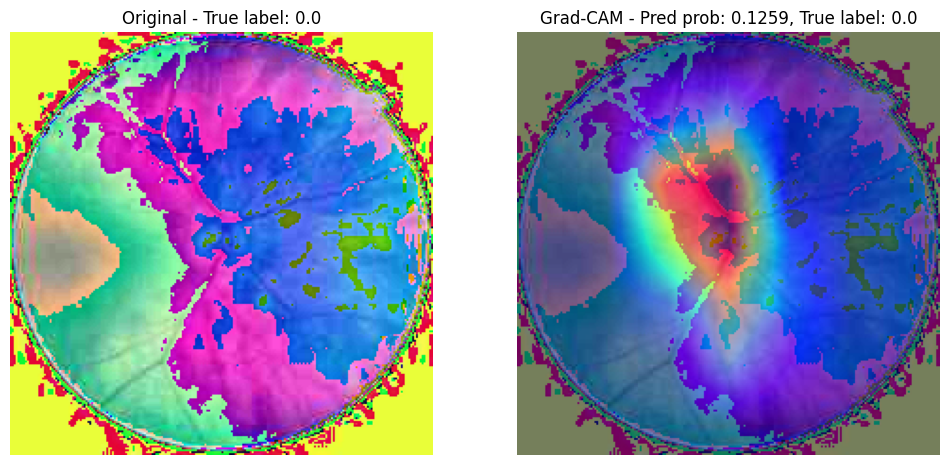

In [ ]:
# model 4 (freeze all layers except fc)

model = models.resnet18(pretrained=True)

# Unfreeze all layers (full fine-tuning)
for param in model.parameters():
    param.requires_grad = True

# Replace FC layer
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Pos weight based on train distribution
train_labels = [full_dataset[i][1].item() for i in train_idx]
pos_weight = torch.tensor(train_labels.count(0)/train_labels.count(1)).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training setup
num_epochs = 20
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels, quality in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss, correct = 0.0, 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for images, labels, quality in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)
            loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.byte()).sum().item()
            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_4.pth")

# -------------------------
# Performance metrics
# -------------------------
precision = precision_score(val_labels, val_preds)
recall = recall_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)
cm = confusion_matrix(val_labels, val_preds)

print("\n----- Validation Metrics -----")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# -------------------------
# Grad-CAM visualization (original + heatmap)
# -------------------------
model.load_state_dict(torch.load("model_4.pth"))
model.eval()
grad_cam = GradCAM(model, model.layer4)

# example: first val sample
val_img, val_label, _ = val_dataset[0]
heatmap, prob = grad_cam.generate(val_img)

# show original + heatmap overlay
img_np = np.array(transforms.ToPILImage()(val_img))
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f'Original - True label: {val_label}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f'Grad-CAM - Pred prob: {prob:.4f}, True label: {val_label}')
plt.axis('off')

plt.show()

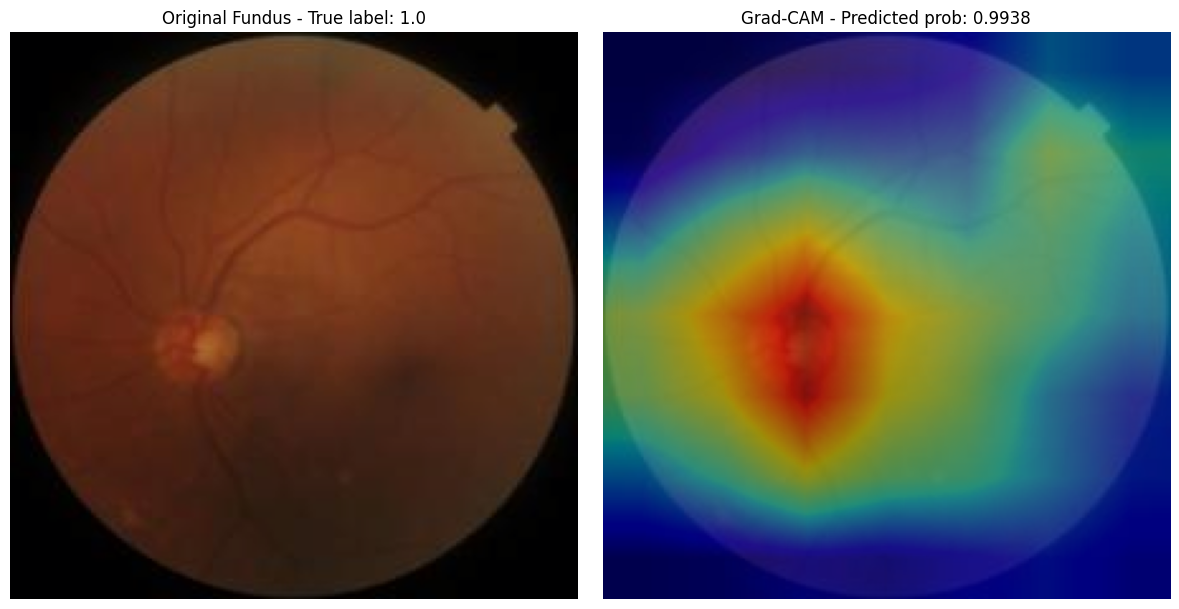

In [ ]:
model.load_state_dict(torch.load("model_4.pth"))
model.eval()

grad_cam = GradCAM(model, model.layer4)

# pick a sample from validation set
val_img, val_label, _ = val_dataset[11]  # first sample
heatmap, prob = grad_cam.generate(val_img)

# unnormalize the original image for proper visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = val_img.numpy().transpose(1,2,0)  # C,H,W -> H,W,C
img_np = std * img_np + mean                # unnormalize
img_np = np.clip(img_np, 0, 1)             # clamp to valid range

# --------------------------
# Side-by-side plot: raw fundus + Grad-CAM
# --------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f'Original Fundus - True label: {val_label}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f'Grad-CAM - Predicted prob: {prob:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()